In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

# EDA

In [46]:
import os
path = r"C:\Users\DuNhan\DSDV_Project\data"
df = pd.read_csv(os.path.join(path, "world.csv"))
df.tail()

,country_geo,year,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Positive affect,Negative affect,Life Ladder,Life Ladder Category
2341,Zimbabwe,2019,7.697755,0.759162,53.099998,0.631908,-0.050874,0.830652,0.658434,0.235354,2.693523,Low
2342,Zimbabwe,2020,7.596050,0.717243,53.575001,0.643303,0.002848,0.788523,0.660658,0.345736,3.159802,Low
2343,Zimbabwe,2021,7.656878,0.685151,54.049999,0.667636,-0.079007,0.756945,0.609917,0.241682,3.154578,Low
2344,Zimbabwe,2022,7.670073,0.666172,54.525002,0.651987,-0.072935,0.752632,0.640609,0.191350,3.296220,Low
2345,Zimbabwe,2023,7.678590,0.693817,55.000000,0.734613,-0.068837,0.757494,0.609752,0.178953,3.572386,Low


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2346 entries, 0 to 2345
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   country_geo                       2346 non-null   object 
 1   year                              2346 non-null   int64  
 2   Log GDP per capita                2346 non-null   float64
 3   Social support                    2346 non-null   float64
 4   Healthy life expectancy at birth  2346 non-null   float64
 5   Freedom to make life choices      2346 non-null   float64
 6   Generosity                        2346 non-null   float64
 7   Perceptions of corruption         2346 non-null   float64
 8   Positive affect                   2346 non-null   float64
 9   Negative affect                   2346 non-null   float64
 10  Life Ladder                       2346 non-null   float64
 11  Life Ladder Category              2346 non-null   object 
dtypes: flo

In [22]:
df.columns

Index(['country_geo', 'year', 'Log GDP per capita', 'Social support',
       'Healthy life expectancy at birth', 'Freedom to make life choices',
       'Generosity', 'Perceptions of corruption', 'Positive affect',
       'Negative affect', 'Life Ladder', 'Life Ladder Category'],
      dtype='object')

In [23]:
cate_cols =['country_geo']
num_cols = ['year', 'Log GDP per capita',
            'Social support', 'Healthy life expectancy at birth',
            'Freedom to make life choices', 'Generosity',
            'Perceptions of corruption', 'Positive affect', 'Negative affect']
target_col = ['Life Ladder']

In [24]:
for col in df.columns:
    print(f"Unique values in {col}:")
    print(df[col].unique())
    print(len(df[col].unique()))
    print("------")

Unique values in country_geo:
['Afghanistan' 'Albania' 'Algeria' 'Angola' 'Argentina' 'Armenia'
 'Australia' 'Austria' 'Azerbaijan' 'Bahrain' 'Bangladesh' 'Belarus'
 'Belgium' 'Belize' 'Benin' 'Bhutan' 'Bolivia' 'Bosnia & Herzegovina'
 'Botswana' 'Brazil' 'Bulgaria' 'Burkina Faso' 'Burundi' 'Cambodia'
 'Cameroon' 'Canada' 'Central African Rep' 'Chad' 'Chile' 'China'
 'Colombia' 'Comoros' 'Congo, Rep of the' 'Congo, Dem Rep of the'
 'Costa Rica' 'Croatia' 'Cuba' 'Cyprus' 'Czechia' 'Denmark' 'Djibouti'
 'Dominican Republic' 'Ecuador' 'Egypt' 'El Salvador' 'Estonia'
 'Swaziland' 'Ethiopia' 'Finland' 'France' 'Gabon' 'Gambia, The' 'Georgia'
 'Germany' 'Ghana' 'Greece' 'Guatemala' 'Guinea' 'Guyana' 'Haiti'
 'Honduras' 'Hungary' 'Iceland' 'India' 'Indonesia' 'Iran' 'Iraq'
 'Ireland' 'Israel' 'Italy' "Cote d'Ivoire" 'Jamaica' 'Japan' 'Jordan'
 'Kazakhstan' 'Kenya' 'Kosovo' 'Kuwait' 'Kyrgyzstan' 'Laos' 'Latvia'
 'Lebanon' 'Lesotho' 'Liberia' 'Libya' 'Lithuania' 'Luxembourg'
 'Madagascar' 'Mala

In [ ]:
# Count the number of records for each country
country_counts = df['country_geo'].value_counts().reset_index()
country_counts.columns = ['country_geo', 'record_count']

# Print the result
print(country_counts)

# Optional: Save the counts to a CSV file
country_counts.to_csv('country_counts.csv', index=False)

    country_geo  record_count
0       Bolivia            18
1    Bangladesh            18
2     Argentina            18
3    Costa Rica            18
4         Chile            18
..          ...           ...
158        Cuba             1
159    Maldives             1
160      Guyana             1
161        Oman             1
162    Suriname             1

[163 rows x 2 columns]


In [36]:
# 1. Filter the data for the specific time range
df_period = df[(df['year'] >= 2010) & (df['year'] <= 2023)]

# 2. Count the number of records for each country in this period
country_counts = df_period['country_geo'].value_counts().reset_index()
country_counts.columns = ['country_geo', 'record_count']

# 3. Print the result
# Ideally, "record_count" should be 14 (one for each year from 2010 to 2023)
print(country_counts)

# 4. Check for incomplete countries
incomplete_countries = country_counts[country_counts['record_count'] < 14]

if not incomplete_countries.empty:
    print("\nCountries with missing years (less than 14 records):")
    print(incomplete_countries)
else:
    print("\nAll countries have complete data for 2010-2023.")

# Optional: Save to CSV
country_counts.to_csv('country_counts_2010_2023.csv', index=False)

    country_geo  record_count
0       Albania            14
1        Canada            14
2     Argentina            14
3       Austria            14
4     Australia            14
..          ...           ...
156    Djibouti             2
157      Belize             1
158    Maldives             1
159        Oman             1
160    Suriname             1

[161 rows x 2 columns]

Countries with missing years (less than 14 records):
     country_geo  record_count
85       Armenia            13
86   Afghanistan            13
87       Morocco            13
88        Zambia            13
89      Paraguay            13
..           ...           ...
156     Djibouti             2
157       Belize             1
158     Maldives             1
159         Oman             1
160     Suriname             1

[76 rows x 2 columns]


--- Data Coverage by Year ---
    year  country_count  coverage_pct
0   2005             27     16.564417
1   2006             88     53.987730
2   2007            102     62.576687
3   2008            109     66.871166
4   2009            112     68.711656
5   2010            122     74.846626
6   2011            144     88.343558
7   2012            139     85.276074
8   2013            136     83.435583
9   2014            143     87.730061
10  2015            142     87.116564
11  2016            140     85.889571
12  2017            146     89.570552
13  2018            141     86.503067
14  2019            142     87.116564
15  2020            115     70.552147
16  2021            121     74.233129
17  2022            139     85.276074
18  2023            138     84.662577

Total unique countries in dataset: 163
Max countries found in a single year: 146

Years with the most complete data (>95% of max):
[2011, 2012, 2014, 2015, 2016, 2017, 2018, 2019, 2022]


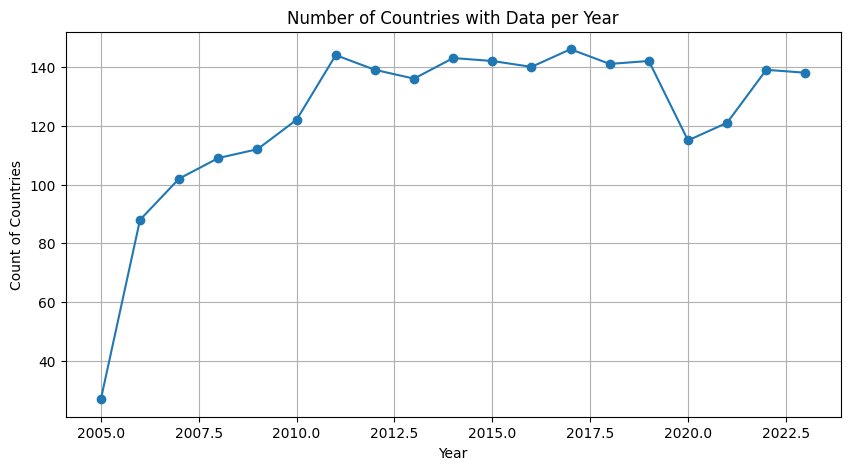

In [ ]:
import matplotlib.pyplot as plt

# 1. Count unique countries per year
coverage_by_year = df.groupby('year')['country_geo'].nunique().reset_index()
coverage_by_year.columns = ['year', 'country_count']

# 2. Calculate the percentage of total countries covered each year
total_unique_countries = df['country_geo'].nunique()
coverage_by_year['coverage_pct'] = (coverage_by_year['country_count'] / total_unique_countries) * 100

# 3. Print the data sorted by year to see the trend
print("--- Data Coverage by Year ---")
print(coverage_by_year)

# 4. Identify the 'best' years (e.g., years with > 90% of the maximum countries observed)
max_countries = coverage_by_year['country_count'].max()
best_years = coverage_by_year[coverage_by_year['country_count'] >= (max_countries * 0.95)]

print(f"\nTotal unique countries in dataset: {total_unique_countries}")
print(f"Max countries found in a single year: {max_countries}")
print(f"\nYears with the most complete data (>95% of max):")
print(best_years['year'].tolist())

# --- Visualize ---
plt.figure(figsize=(10, 5))
plt.plot(coverage_by_year['year'], coverage_by_year['country_count'], marker='o')
plt.title('Number of Countries with Data per Year')
plt.xlabel('Year')
plt.ylabel('Count of Countries')
plt.grid(True)
plt.show()

In [58]:
import pandas as pd
import numpy as np
import os
import shutil

# ==========================================
# 1. CONFIGURATION & MAPPINGS
# ==========================================

PATH = r"C:\Users\DuNhan\DSDV_Project\data"
INPUT_FILE = 'world.csv'

# Map specific countries to 5 broad regions
country_to_region = {
    # --- Africa ---
    'Algeria': 'Africa', 'Angola': 'Africa', 'Benin': 'Africa', 'Botswana': 'Africa', 
    'Burkina Faso': 'Africa', 'Burundi': 'Africa', 'Cameroon': 'Africa', 
    'Central African Rep': 'Africa', 'Chad': 'Africa', 'Comoros': 'Africa', 
    'Congo, Rep of the': 'Africa', 'Congo, Dem Rep of the': 'Africa', "Cote d'Ivoire": 'Africa', 
    'Djibouti': 'Africa', 'Egypt': 'Africa', 'Swaziland': 'Africa', 'Ethiopia': 'Africa', 
    'Gabon': 'Africa', 'Gambia, The': 'Africa', 'Ghana': 'Africa', 'Guinea': 'Africa', 
    'Kenya': 'Africa', 'Lesotho': 'Africa', 'Liberia': 'Africa', 'Libya': 'Africa', 
    'Madagascar': 'Africa', 'Malawi': 'Africa', 'Mali': 'Africa', 'Mauritania': 'Africa', 
    'Mauritius': 'Africa', 'Morocco': 'Africa', 'Mozambique': 'Africa', 'Namibia': 'Africa', 
    'Niger': 'Africa', 'Nigeria': 'Africa', 'Rwanda': 'Africa', 'Senegal': 'Africa', 
    'Sierra Leone': 'Africa', 'Somalia': 'Africa', 'South Africa': 'Africa', 
    'South Sudan': 'Africa', 'Sudan': 'Africa', 'Tanzania': 'Africa', 'Togo': 'Africa', 
    'Tunisia': 'Africa', 'Uganda': 'Africa', 'Zambia': 'Africa', 'Zimbabwe': 'Africa',

    # --- The Americas ---
    'Belize': 'The Americas', 'Canada': 'The Americas', 'Costa Rica': 'The Americas', 
    'Cuba': 'The Americas', 'Dominican Republic': 'The Americas', 'El Salvador': 'The Americas', 
    'Guatemala': 'The Americas', 'Haiti': 'The Americas', 'Honduras': 'The Americas', 
    'Jamaica': 'The Americas', 'Mexico': 'The Americas', 'Nicaragua': 'The Americas', 
    'Panama': 'The Americas', 'Trinidad & Tobago': 'The Americas', 'United States': 'The Americas',
    'Argentina': 'The Americas', 'Bolivia': 'The Americas', 'Brazil': 'The Americas', 
    'Chile': 'The Americas', 'Colombia': 'The Americas', 'Ecuador': 'The Americas', 
    'Guyana': 'The Americas', 'Paraguay': 'The Americas', 'Peru': 'The Americas', 
    'Suriname': 'The Americas', 'Uruguay': 'The Americas', 'Venezuela': 'The Americas',

    # --- Europe ---
    'Albania': 'Europe', 'Austria': 'Europe', 'Belarus': 'Europe', 'Belgium': 'Europe', 
    'Bosnia & Herzegovina': 'Europe', 'Bulgaria': 'Europe', 'Croatia': 'Europe', 
    'Czechia': 'Europe', 'Denmark': 'Europe', 'Estonia': 'Europe', 'Finland': 'Europe', 
    'France': 'Europe', 'Germany': 'Europe', 'Greece': 'Europe', 'Hungary': 'Europe', 
    'Iceland': 'Europe', 'Ireland': 'Europe', 'Italy': 'Europe', 'Kosovo': 'Europe', 
    'Latvia': 'Europe', 'Lithuania': 'Europe', 'Luxembourg': 'Europe', 'Macedonia': 'Europe', 
    'Malta': 'Europe', 'Moldova': 'Europe', 'Montenegro': 'Europe', 'Netherlands': 'Europe', 
    'Norway': 'Europe', 'Poland': 'Europe', 'Portugal': 'Europe', 'Romania': 'Europe', 
    'Russia': 'Europe', 'Serbia': 'Europe', 'Slovakia': 'Europe', 'Slovenia': 'Europe', 
    'Spain': 'Europe', 'Sweden': 'Europe', 'Switzerland': 'Europe', 'Ukraine': 'Europe', 
    'United Kingdom': 'Europe',

    # --- Asia ---
    'Armenia': 'Asia', 'Azerbaijan': 'Asia', 'Bahrain': 'Asia', 
    'Cyprus': 'Asia', 'Georgia': 'Asia', 'Iran': 'Asia', 
    'Iraq': 'Asia', 'Israel': 'Asia', 'Jordan': 'Asia', 
    'Kuwait': 'Asia', 'Lebanon': 'Asia', 'Oman': 'Asia', 
    'Qatar': 'Asia', 'Saudi Arabia': 'Asia', 'Syria': 'Asia', 
    'Turkey': 'Asia', 'United Arab Emirates': 'Asia', 'West Bank': 'Asia', 
    'Yemen': 'Asia',
    'Kazakhstan': 'Asia', 'Kyrgyzstan': 'Asia', 'Tajikistan': 'Asia', 
    'Turkmenistan': 'Asia', 'Uzbekistan': 'Asia',
    'Afghanistan': 'Asia', 'Bangladesh': 'Asia', 'Bhutan': 'Asia', 
    'India': 'Asia', 'Maldives': 'Asia', 'Nepal': 'Asia', 
    'Pakistan': 'Asia', 'Sri Lanka': 'Asia',
    'China': 'Asia', 'Japan': 'Asia', 'Korea, South': 'Asia', 
    'Mongolia': 'Asia', 'Taiwan': 'Asia',
    'Burma': 'Asia', 'Cambodia': 'Asia', 'Indonesia': 'Asia', 
    'Laos': 'Asia', 'Malaysia': 'Asia', 'Philippines': 'Asia', 
    'Singapore': 'Asia', 'Thailand': 'Asia', 'Vietnam': 'Asia',

    # --- Oceania ---
    'Australia': 'Oceania', 'New Zealand': 'Oceania'
}

name_mapping = {
    "Bosnia & Herzegovina": "Bosnia and Herzegovina",
    "Burma": "Myanmar",
    "Central African Rep": "Central African Republic",
    "Congo, Dem Rep of the": "Democratic Republic of the Congo",
    "Congo, Rep of the": "Republic of the Congo",
    "Cote d'Ivoire": "Ivory Coast",
    "Czechia": "Czech Republic",
    "Gambia, The": "Gambia",
    "Korea, South": "South Korea",
    "Serbia": "Republic of Serbia",
    "Tanzania": "United Republic of Tanzania",
    "Trinidad & Tobago": "Trinidad and Tobago",
    "United Kingdom": "England",  
    "United States": "USA"
}

# ==========================================
# 2. LOAD & INITIAL PREP
# ==========================================

print("Loading data...")
try:
    df = pd.read_csv(os.path.join(PATH, INPUT_FILE))
except FileNotFoundError:
    print(f"Error: {INPUT_FILE} not found.")
    exit()

# Apply Region Mapping
df['region'] = df['country_geo'].map(country_to_region)
missed = df[df['region'].isna()]['country_geo'].unique()
if len(missed) > 0: print(f"Warning: Unmapped regions: {missed}")

# Apply Name Corrections
df['country_geo'] = df['country_geo'].replace(name_mapping)

# ==========================================
# 3. FILTER TIME RANGE
# ==========================================
print("Filtering 2010-2023...")
df_period = df[(df['year'] >= 2010) & (df['year'] <= 2023)].copy()

# ==========================================
# 4. REMOVE SPARSE COUNTRIES
# ==========================================
# Rule: Keep countries with at least 7 records in this period
country_counts = df_period['country_geo'].value_counts()
countries_to_keep = country_counts[country_counts >= 7].index

df_clean = df_period[df_period['country_geo'].isin(countries_to_keep)].copy()

print(f"Original Countries: {len(country_counts)}")
print(f"Removed (<7 records): {len(country_counts) - len(countries_to_keep)}")
print(f"Remaining Countries: {len(countries_to_keep)}")

# ==========================================
# 5. DATA IMPUTATION (SKELETON & INTERPOLATION)
# ==========================================
print("Interpolating missing years...")

# A. Create Skeleton (Every country must have years 2010-2023)
years = range(2010, 2024)
skeleton = pd.MultiIndex.from_product(
    [countries_to_keep, years], 
    names=['country_geo', 'year']
).to_frame(index=False)

# B. Merge (Creates NaNs for missing years)
df_full = pd.merge(skeleton, df_clean, on=['country_geo', 'year'], how='left')
df_full = df_full.sort_values(by=['country_geo', 'year'])

# C. Fill Static Column 'region'
df_full['region'] = df_full.groupby('country_geo')['region'].ffill().bfill()

# D. Interpolation Function
def interpolate_group(group):
    # Select numeric columns for interpolation
    numeric_cols = group.select_dtypes(include=[np.number]).columns
    group[numeric_cols] = group[numeric_cols].interpolate(method='linear', limit_direction='both')
    # Fill remaining edges
    group[numeric_cols] = group[numeric_cols].ffill().bfill()
    return group

# Apply interpolation
df_imputed = df_full.groupby('country_geo').apply(interpolate_group)
df_imputed = df_imputed.reset_index(drop=True)

# E. Re-calculate 'Life Ladder Category' for new rows
# Since interpolation creates new Life Ladder values, we must re-assign Low/Med/High
def categorize(score):
    if pd.isna(score): return None
    if score < 5: return 'Low'
    elif score < 6.5: return 'Medium'
    else: return 'High'

df_imputed['Life Ladder Category'] = df_imputed['Life Ladder'].apply(categorize)

# ==========================================
# 6. EXPORT FINAL FILES
# ==========================================
print("Generating output files...")

# A. Main Dataset (Full History)
df_imputed.to_csv(os.path.join(PATH, 'world_with_regions.csv'), index=False)
print("1. world_with_regions.csv created.")

# B. Regional Averages (For Bottom Line Chart)
# Exclude non-numeric for aggregation
numeric_cols = df_imputed.select_dtypes(include=['number']).columns.tolist()
if 'year' in numeric_cols: numeric_cols.remove('year')

regional_avg = df_imputed.groupby(['region', 'year'])[numeric_cols].mean().reset_index()
regional_avg.to_csv(os.path.join(PATH, 'regional_averages.csv'), index=False)
print("2. regional_averages.csv created.")

# C. World Averages (For Dotted Line)
world_avg = df_imputed.groupby('year')[numeric_cols].mean().reset_index()
world_avg.to_csv(os.path.join(PATH, 'world_grouped_by_year.csv'), index=False)
print("3. world_grouped_by_year.csv created.")

# D. Yearly Files (For Map Slider)
output_dir = os.path.join(PATH, 'yearly_files')
if os.path.exists(output_dir):
    shutil.rmtree(output_dir)
os.makedirs(output_dir)

for year in years:
    year_data = df_imputed[df_imputed['year'] == year]
    year_data.to_csv(os.path.join(output_dir, f'world_{year}.csv'), index=False)

print(f"4. Yearly files (2010-2023) created in '{output_dir}/'")
print("\nPipeline Complete. Dashboard data is ready.")

Loading data...
Filtering 2010-2023...
Original Countries: 161
Removed (<7 records): 18
Remaining Countries: 143
Interpolating missing years...
Generating output files...
1. world_with_regions.csv created.
2. regional_averages.csv created.
3. world_grouped_by_year.csv created.
4. Yearly files (2010-2023) created in 'C:\Users\DuNhan\DSDV_Project\data\yearly_files/'

Pipeline Complete. Dashboard data is ready.


C:\Users\DuNhan\AppData\Local\Temp\ipykernel_5112\663932849.py:161: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_imputed = df_full.groupby('country_geo').apply(interpolate_group)


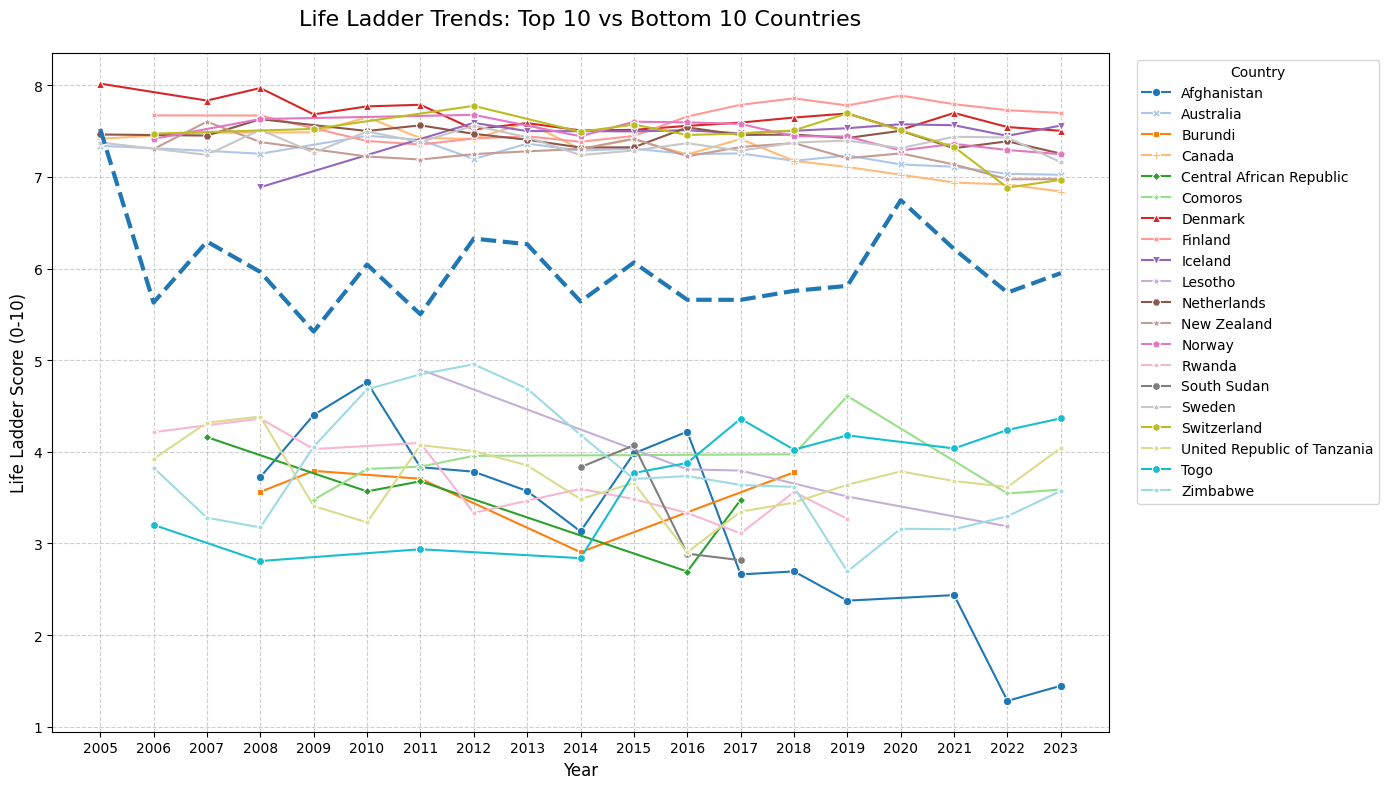

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the columns are named correctly as per your data
# Expected: 'country_geo', 'year', 'Life Ladder'

# 2. Select countries to plot to avoid overcrowding
# We will pick the Top 10 and Bottom 10 countries by average Life Ladder score
avg_happiness = df.groupby('country_geo')['Life Ladder'].mean().sort_values(ascending=False)

top_10_countries = avg_happiness.head(10).index.tolist()
bottom_10_countries = avg_happiness.tail(10).index.tolist()
selected_countries = top_10_countries + bottom_10_countries

# Filter the dataframe
plot_data = df[df['country_geo'].isin(selected_countries)]

# 3. Create the Time Series Plot
plt.figure(figsize=(14, 8))

# Use seaborn for easier handling of groups (hue)
sns.lineplot(
    data=plot_data,
    x='year',
    y='Life Ladder',
    hue='country_geo',
    style='country_geo', # Adds different line styles for better distinction
    markers=True,
    dashes=False,
    palette='tab20'       # A palette with many distinct colors
)

# Customizing the plot
plt.title('Life Ladder Trends: Top 10 vs Bottom 10 Countries', fontsize=16, pad=20)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Life Ladder Score (0-10)', fontsize=12)
plt.legend(title='Country', bbox_to_anchor=(1.02, 1), loc='upper left') # Move legend outside
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(df['year'].unique()) # Ensure all years are shown on x-axis
plt.tight_layout()

# Add mean Life Ladder line
# Compute mean Life Ladder per year
mean_per_year = (
    plot_data
    .groupby('year')['Life Ladder']
    .mean()
    .reset_index()
)

# Plot mean per year line
plt.plot(
    mean_per_year['year'],
    mean_per_year['Life Ladder'],
    linestyle='--',
    linewidth=3,
    label='Mean Life Ladder per Year'
)

# 4. Show the plot
plt.show()

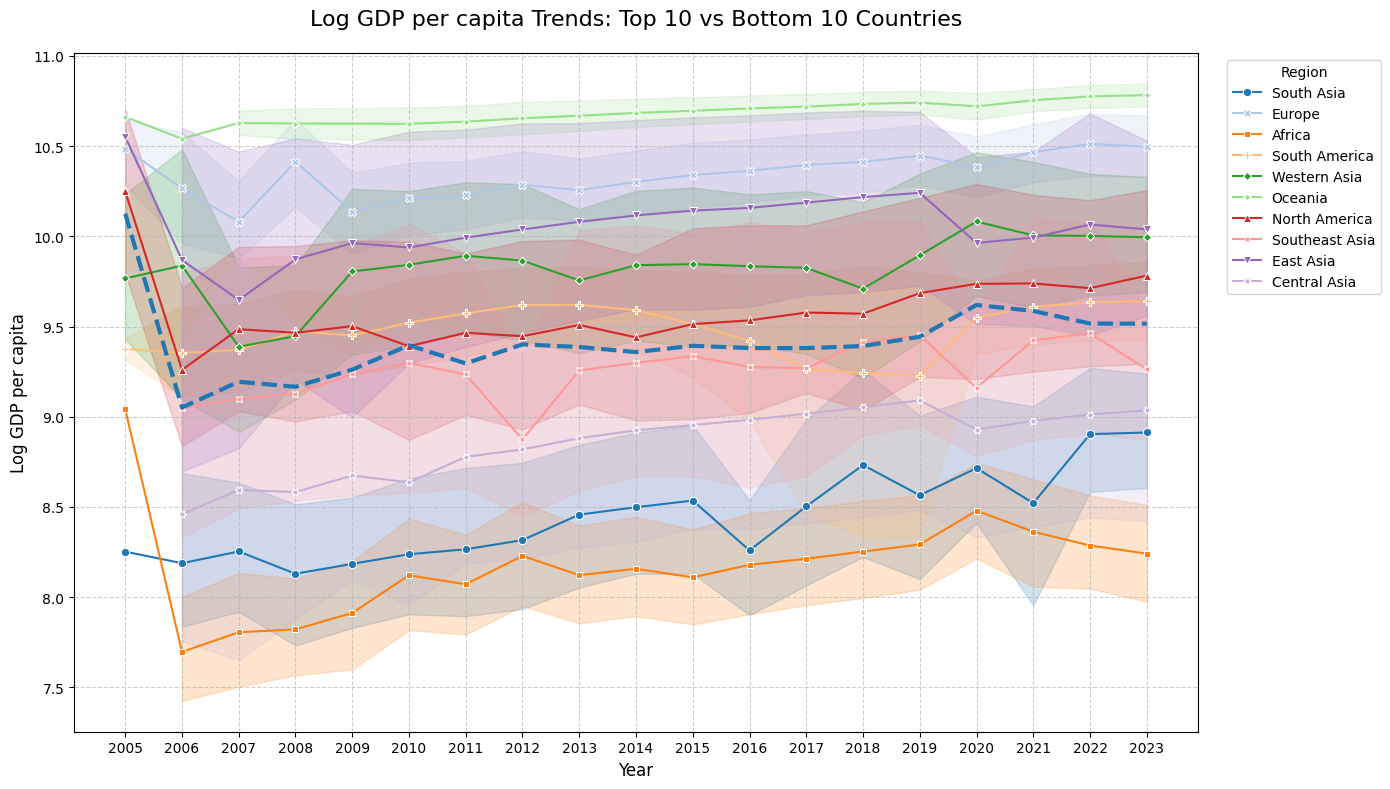

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the columns are named correctly as per your data
# Expected: 'country_geo', 'year', 'Life Ladder'

# 2. Select countries to plot to avoid overcrowding
# We will pick the Top 10 and Bottom 10 countries by average Life Ladder score
avg_happiness = df.groupby('region')['Log GDP per capita'].mean().sort_values(ascending=False)

top_10_countries = avg_happiness.head(85).index.tolist()
bottom_10_countries = avg_happiness.tail(80).index.tolist()
selected_countries = top_10_countries + bottom_10_countries

# Filter the dataframe
plot_data = df[df['region'].isin(selected_countries)]

# 3. Create the Time Series Plot
plt.figure(figsize=(14, 8))

# Use seaborn for easier handling of groups (hue)
sns.lineplot(
    data=plot_data,
    x='year',
    y='Log GDP per capita',
    hue='region',
    style='region', # Adds different line styles for better distinction
    markers=True,
    dashes=False,
    palette='tab20'       # A palette with many distinct colors
)

# Customizing the plot
plt.title('Log GDP per capita Trends: Top 10 vs Bottom 10 Countries', fontsize=16, pad=20)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Log GDP per capita', fontsize=12)
plt.legend(title='Region', bbox_to_anchor=(1.02, 1), loc='upper left') # Move legend outside
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(df['year'].unique()) # Ensure all years are shown on x-axis
plt.tight_layout()

# Add mean Life Ladder line
# Compute mean Life Ladder per year
mean_per_year = (
    plot_data
    .groupby('year')['Log GDP per capita']
    .mean()
    .reset_index()
)

# Plot mean per year line
plt.plot(
    mean_per_year['year'],
    mean_per_year['Log GDP per capita'],
    linestyle='--',
    linewidth=3,
    label='Mean Log GDP per capita per Year'
)

# 4. Show the plot
plt.show()

/tmp/ipython-input-1347588796.py:31: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


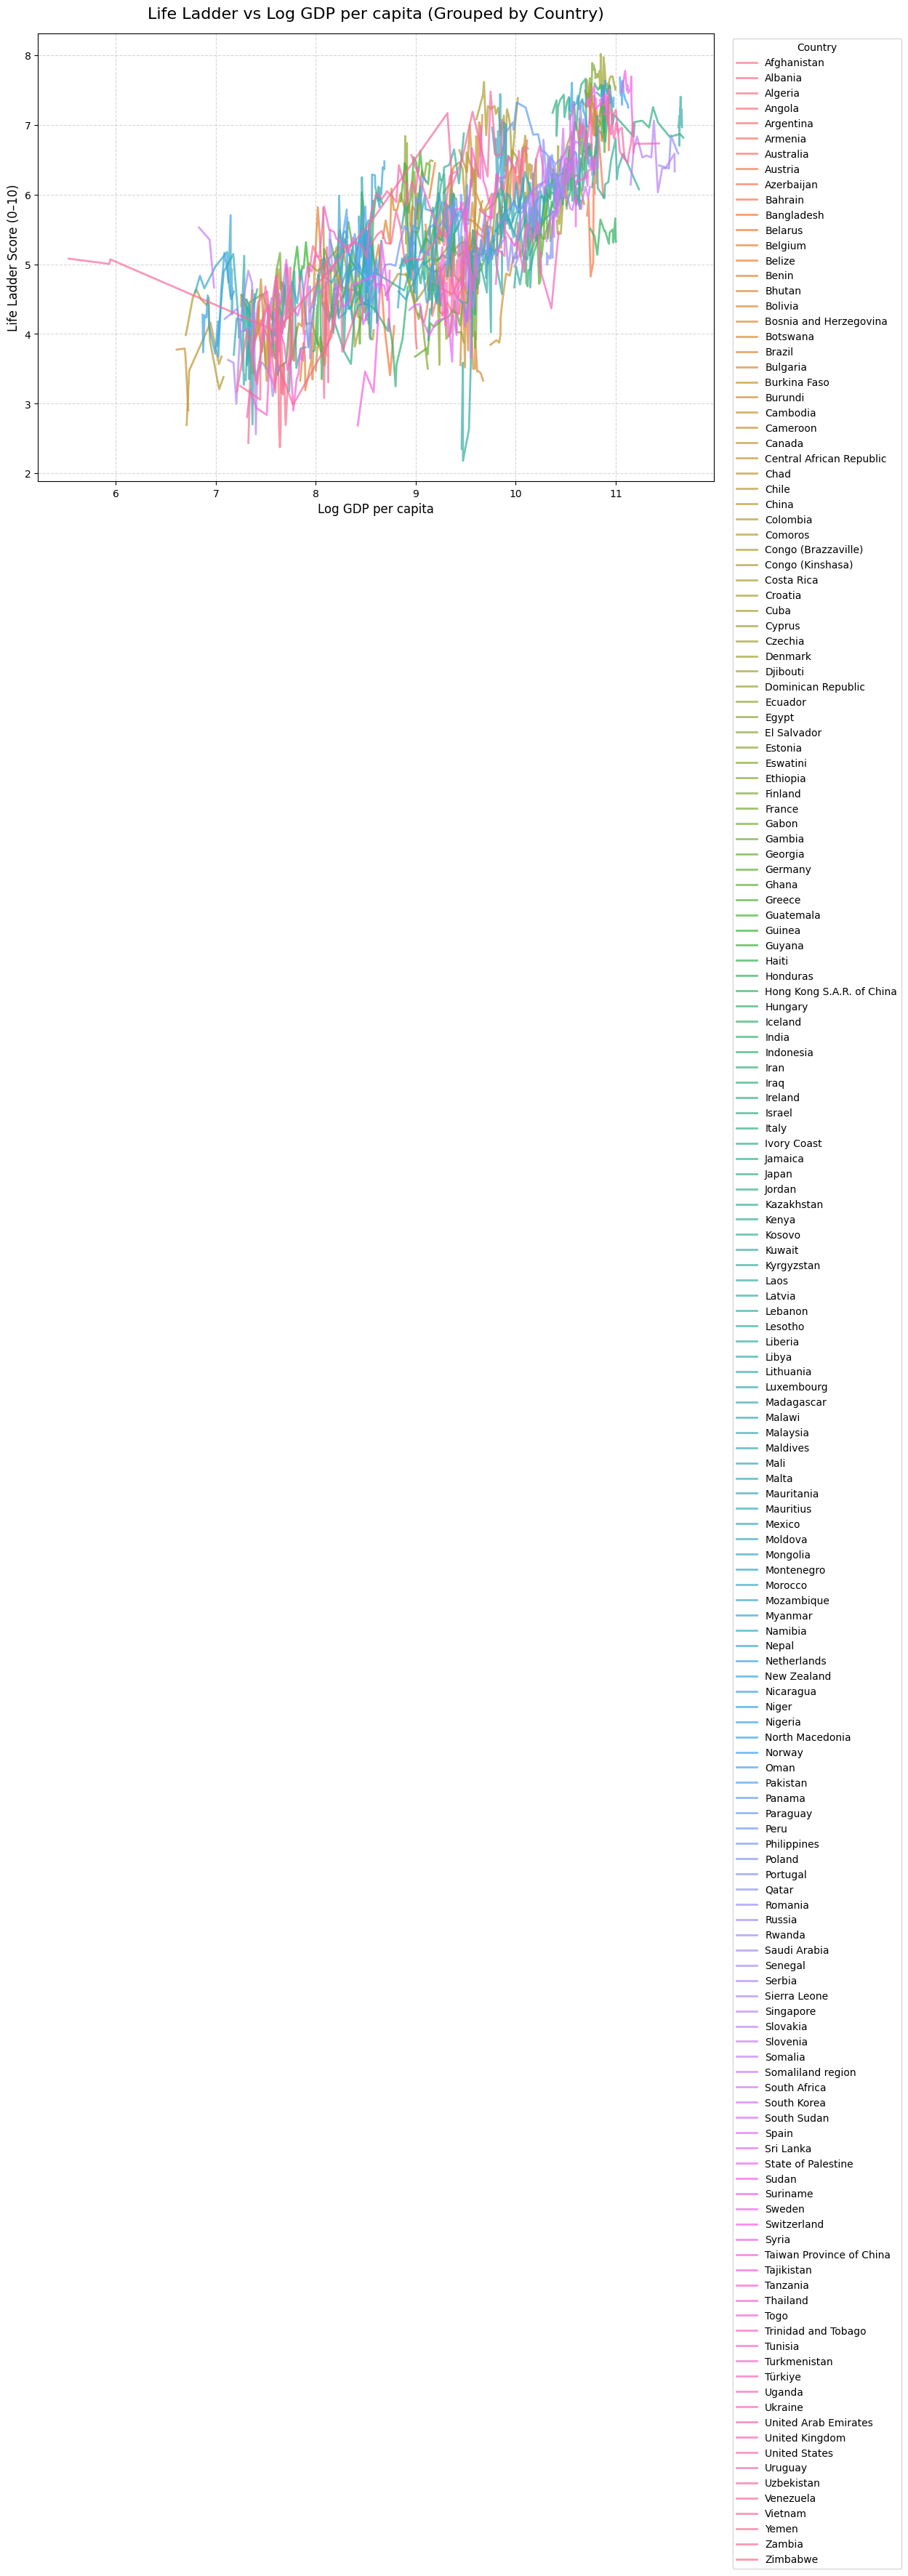

In [ ]:
plot_data = plot_data.sort_values(
    by=['country_geo', 'year']
)
plt.figure(figsize=(12, 8))

sns.lineplot(
    data=plot_data,
    x='Log GDP per capita',
    y='Life Ladder',
    hue='country_geo',
    units='country_geo',     # ensures one line per country
    estimator=None,           # prevents averaging across countries
    linewidth=2,
    alpha=0.7
)

plt.title(
    'Life Ladder vs Log GDP per capita (Grouped by Country)',
    fontsize=16,
    pad=15
)
plt.xlabel('Log GDP per capita', fontsize=12)
plt.ylabel('Life Ladder Score (0–10)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(
    title='Country',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)
plt.tight_layout()
plt.show()


In [ ]:
# Define the bins and labels
bins = [0, 5, 7, 10]
labels = ['Low', 'Medium', 'High']

# Create categorical column
df['Life Ladder Category'] = pd.cut(df['Life Ladder'], bins=bins, labels=labels, include_lowest=True)

# Check result
print(df[['Life Ladder', 'Life Ladder Category']].head())


   Life Ladder Life Ladder Category
0     3.723590                  Low
1     4.401778                  Low
2     4.758381                  Low
3     3.831719                  Low
4     3.782938                  Low


/tmp/ipython-input-573282618.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Life Ladder Category', palette='Set2')


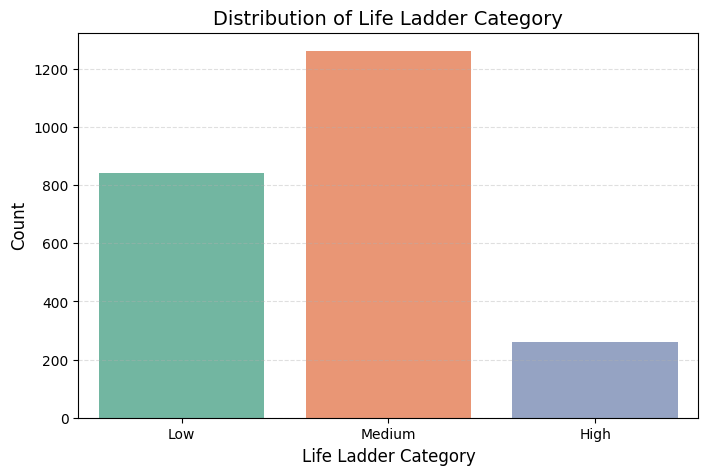

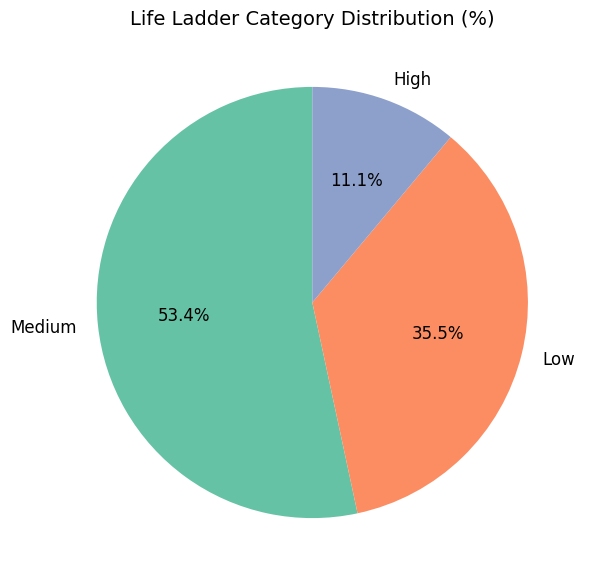

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ============================
# 1. Count distribution (barplot)
# ============================

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Life Ladder Category', palette='Set2')

plt.title("Distribution of Life Ladder Category", fontsize=14)
plt.xlabel("Life Ladder Category", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

# ============================
# 2. Pie chart (optional)
# ============================

plt.figure(figsize=(7, 7))

df['Life Ladder Category'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette("Set2"),
    textprops={'fontsize': 12}
)

plt.title("Life Ladder Category Distribution (%)", fontsize=14)
plt.ylabel("")   # remove y-label for cleaner look
plt.show()


In [ ]:
df[num_cols].isnull().sum()

,0
year,0
Log GDP per capita,28
Social support,13
Healthy life expectancy at birth,63
Freedom to make life choices,36
Generosity,81
Perceptions of corruption,125
Positive affect,24
Negative affect,16


In [ ]:
df.describe()

,year,Life Ladder,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Positive affect,Negative affect
count,2363.000000,2363.000000,2335.000000,2350.000000,2300.000000,2327.000000,2282.000000,2238.000000,2339.000000,2347.000000
mean,2014.763860,5.483562,9.399673,0.809369,63.401828,0.750290,0.000096,0.743959,0.651878,0.273160
std,5.059436,1.125523,1.152062,0.121211,6.842644,0.139366,0.161386,0.184871,0.106249,0.087133
min,2005.000000,1.281271,5.526723,0.228217,6.720000,0.228301,-0.339547,0.035198,0.178886,0.082737
25%,2011.000000,4.646750,8.506165,0.743811,59.195001,0.660706,-0.111940,0.686784,0.571977,0.208559
50%,2015.000000,5.448725,9.502946,0.834395,65.099998,0.771122,-0.021613,0.798497,0.663420,0.262175
75%,2019.000000,6.323592,10.392974,0.903779,68.552502,0.861740,0.093569,0.867557,0.737262,0.326211
max,2023.000000,8.018934,11.675588,0.987343,74.599998,0.985178,0.699570,0.983276,0.883586,0.704590


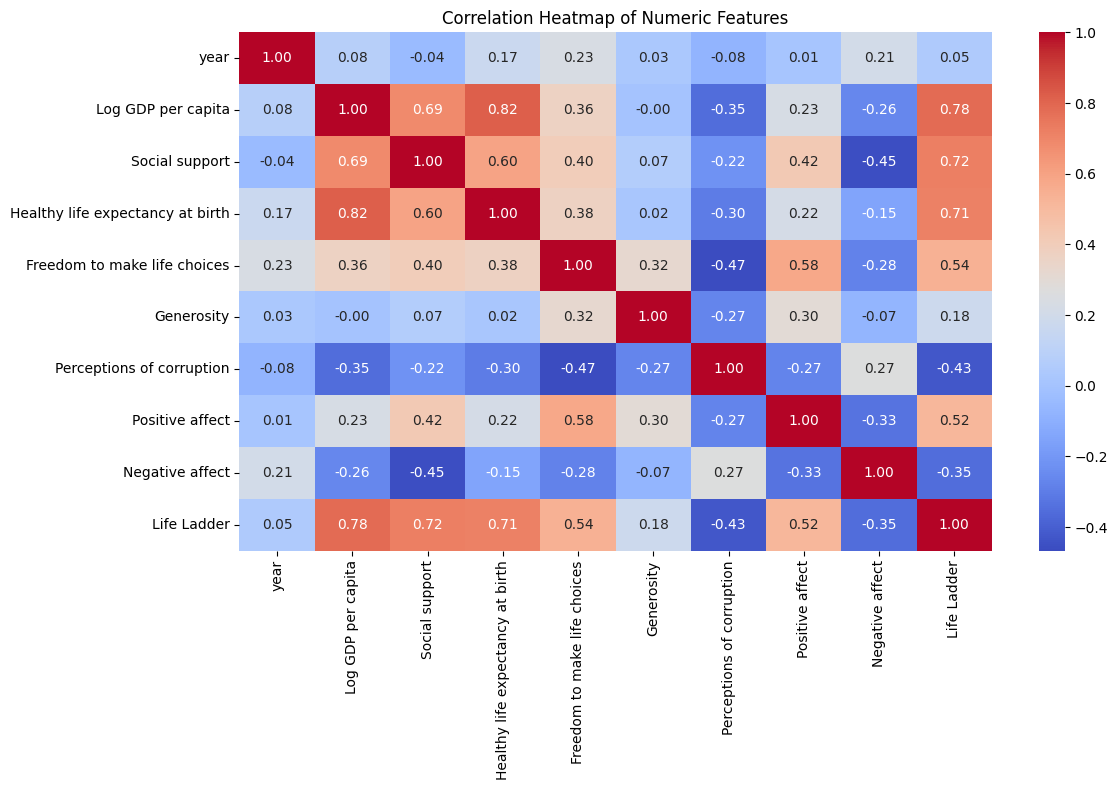

In [ ]:
corr_matrix = df[num_cols+target_col].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()